# Graph Analysis – Part 3: Advanced Analytics

This notebook performs the following advanced analyses as requested:

1. **Removal of Isolated Nodes**: Nodes with degree 0 are removed, and all calculations are performed on the remaining graph.
2. **Component Distributions**: Histograms are created for the sizes of weakly and strongly connected components.
3. **Eigenvector Centrality**: Calculated in addition to existing metrics.
4. **Community Similarity Analysis**: Homogeneity analysis is performed by comparing the cosine similarity of intra-community and inter-community links.
5. **Degree vs. Similarity Box Plot**: Nodes are grouped by degree ranges to analyze average neighbor similarity.

## 1. Setup and Data Loading

In [9]:
import json, os, pickle
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity

CACHE_DIR = '../../cache'
os.makedirs(CACHE_DIR, exist_ok=True)

def compute_or_load(name, compute_fn, force=False):
    path = os.path.join(CACHE_DIR, f'analysis3_{name}.pkl')
    if os.path.exists(path) and not force:
        print(f'  ✓ {name} loaded from cache.')
        with open(path, 'rb') as f:
            return pickle.load(f)
    print(f'  ⏳ Computing {name}…')
    result = compute_fn()
    with open(path, 'wb') as f:
        pickle.dump(result, f)
    print(f'  ✓ {name} computed and saved.')
    return result

# Premium visualization settings
plt.style.use('bmh')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 12

In [10]:
# Load data
with open('../../data/data-embeddings.json', 'r') as f:
    raw_data = json.load(f)

# Embeddings (Loaded from correct folder)
df_embeddings = pd.read_parquet('../../cap-embeddings/BAAI_bge-m3/master_embeddings.parquet')
embedding_dict = dict(zip(df_embeddings['id'].astype(int), df_embeddings['embedding']))

print(f"Total node data: {len(raw_data['nodes'])}")
print(f"Nodes with embedding data: {len(df_embeddings)}")

Total node data: 11701
Nodes with embedding data: 11701


## 2. Removal of Isolated Nodes

Nodes with degree 0 are removed from the graph.

In [11]:
# Temporary graph to find isolates
node_ids = {n['id'] for n in raw_data['nodes']}
G_temp = nx.DiGraph()
for n in raw_data['nodes']:
    G_temp.add_node(n['id'], title=n['title'], label=n.get('label', 'Unknown'))
for n in raw_data['nodes']:
    src = n['id']
    for tgt in n.get('outlinks', []):
        if tgt in node_ids:
            G_temp.add_edge(src, tgt)

# Find isolated nodes
isolated_nodes = list(nx.isolates(G_temp))
print(f"Number of isolated nodes removed: {len(isolated_nodes)}")

# Create cleaned graph
G = G_temp.copy()
G.remove_nodes_from(isolated_nodes)
G_und = G.to_undirected()

print(f"New node count: {G.number_of_nodes()}")
print(f"New edge count: {G.number_of_edges()}")

Number of isolated nodes removed: 334
New node count: 11367
New edge count: 291039


## 3. Component Distributions

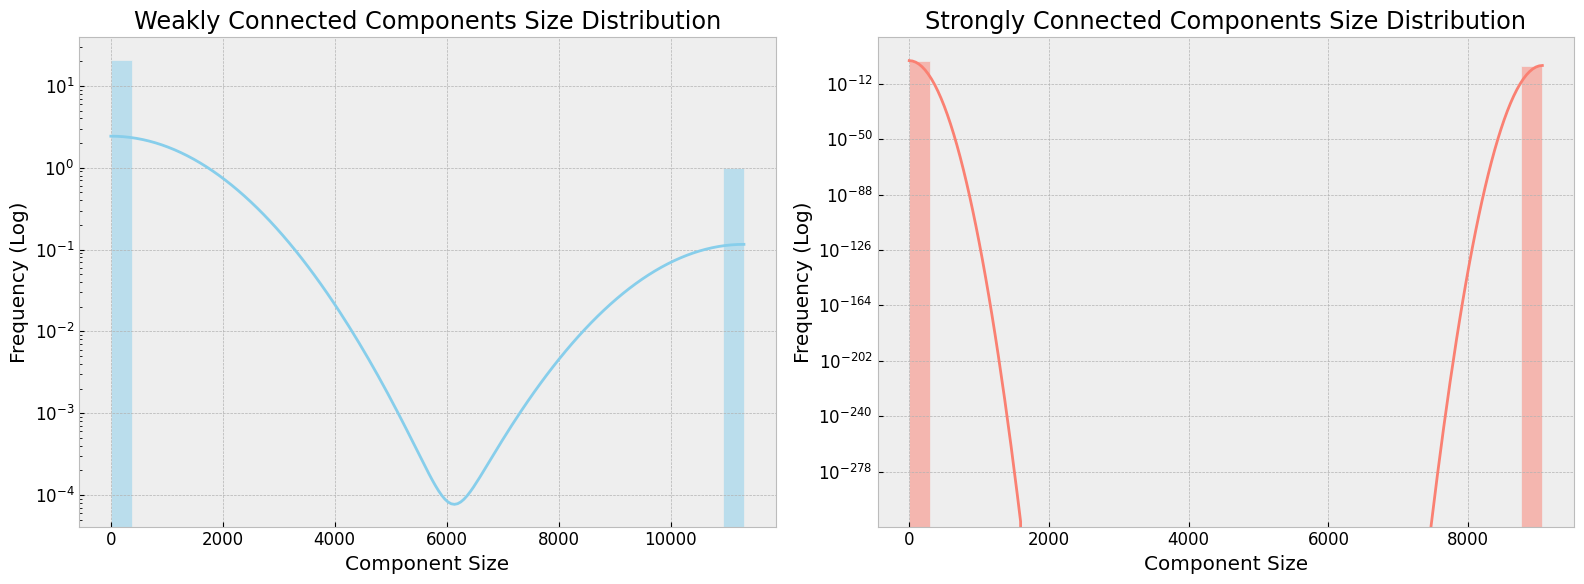

In [12]:
wcc_sizes = [len(c) for c in nx.weakly_connected_components(G)]
scc_sizes = [len(c) for c in nx.strongly_connected_components(G)]

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(wcc_sizes, bins=30, kde=True, ax=ax[0], color='skyblue')
ax[0].set_title('Weakly Connected Components Size Distribution')
ax[0].set_yscale('log')
ax[0].set_xlabel('Component Size')
ax[0].set_ylabel('Frequency (Log)')

sns.histplot(scc_sizes, bins=30, kde=True, ax=ax[1], color='salmon')
ax[1].set_title('Strongly Connected Components Size Distribution')
ax[1].set_yscale('log')
ax[1].set_xlabel('Component Size')
ax[1].set_ylabel('Frequency (Log)')

plt.tight_layout()
plt.show()

## 4. Centrality Calculations

All centrality metrics are recalculated on the cleaned graph.

In [13]:
degree_cent = compute_or_load('degree_centrality', lambda: nx.degree_centrality(G))
betweenness_cent = compute_or_load('betweenness_centrality', lambda: nx.betweenness_centrality(G_und))
closeness_cent = compute_or_load('closeness_centrality', lambda: nx.closeness_centrality(G_und))
pagerank_cent = compute_or_load('pagerank', lambda: nx.pagerank(G))
eigenvector_cent = compute_or_load('eigenvector_centrality', lambda: nx.eigenvector_centrality(G_und, max_iter=1000))

def get_stats(name, d):
    vals = list(d.values())
    return {'Metric': name, 'Min': np.min(vals), 'Max': np.max(vals), 'Mean': np.mean(vals), 'Std': np.std(vals)}

stats_df = pd.DataFrame([
    get_stats('Degree', degree_cent),
    get_stats('Betweenness', betweenness_cent),
    get_stats('Closeness', closeness_cent),
    get_stats('PageRank', pagerank_cent),
    get_stats('Eigenvector', eigenvector_cent)
])
print(stats_df.to_string(index=False))

  ✓ degree_centrality loaded from cache.
  ✓ betweenness_centrality loaded from cache.
  ✓ closeness_centrality loaded from cache.
  ✓ pagerank loaded from cache.
  ✓ eigenvector_centrality loaded from cache.
     Metric          Min      Max     Mean      Std
     Degree 8.798170e-05 0.305648 0.004505 0.007880
Betweenness 0.000000e+00 0.215722 0.000176 0.002481
  Closeness 0.000000e+00 0.550493 0.333407 0.045880
   PageRank 1.344861e-05 0.010007 0.000088 0.000209
Eigenvector 5.343081e-55 0.211245 0.004355 0.008307


## 5. Community Similarity Analysis

Similarity of intra-community links vs inter-community links is compared.

In [14]:
import community as community_louvain

partition = community_louvain.best_partition(G_und)
nx.set_node_attributes(G, partition, 'community')

intra_sims = []
inter_sims = []

for u, v in G.edges():
    if u in embedding_dict and v in embedding_dict:
        sim = cosine_similarity(embedding_dict[u].reshape(1, -1), embedding_dict[v].reshape(1, -1))[0][0]
        if partition[u] == partition[v]:
            intra_sims.append(sim)
        else:
            inter_sims.append(sim)

print(f"Average similarity within communities (intra): {np.mean(intra_sims):.4f}")
print(f"Average similarity between communities (inter): {np.mean(inter_sims):.4f}")

Average similarity within communities (intra): 0.5795
Average similarity between communities (inter): 0.5481


## 6. Degree vs. Similarity Box Plot

Average neighbor similarity is examined based on node degree ranges.

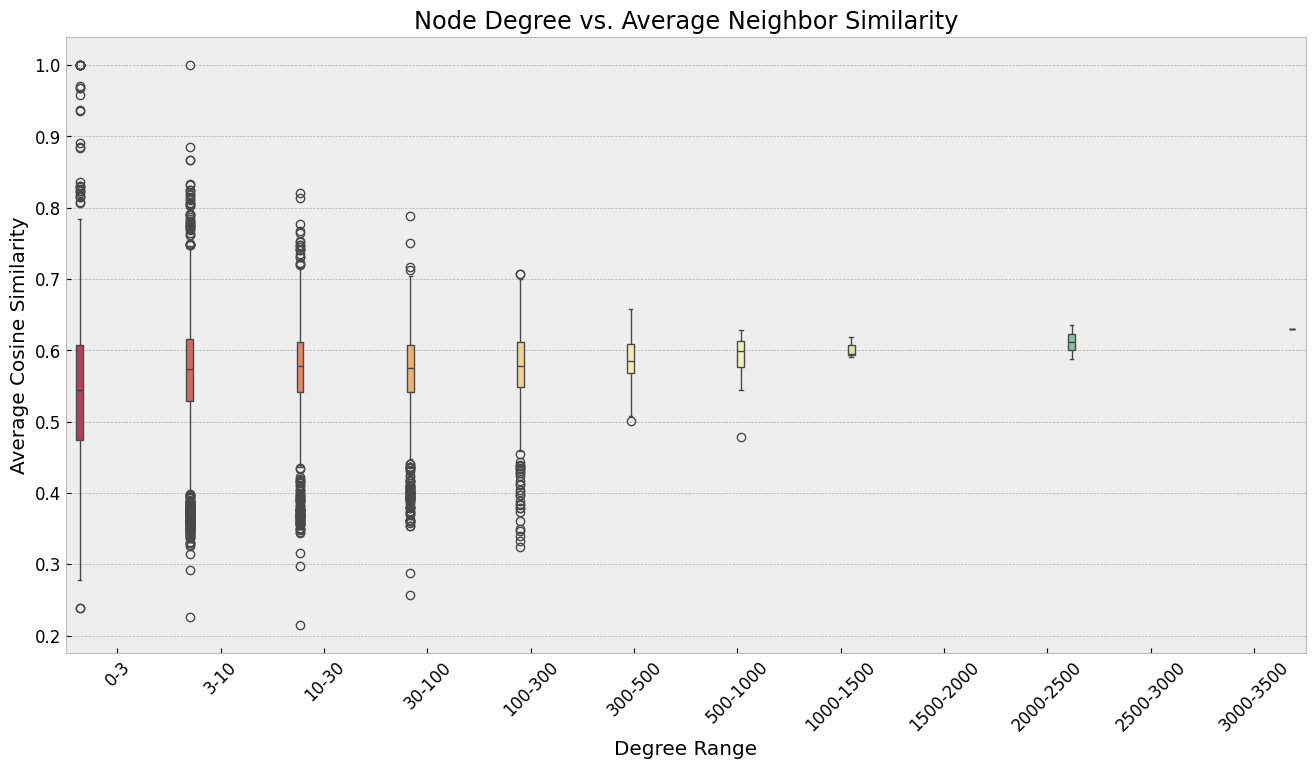

In [15]:
node_similarities = []
for u in G.nodes():
    neighbors = list(G.neighbors(u))
    if not neighbors or u not in embedding_dict:
        continue
    
    sims = []
    u_emb = embedding_dict[u].reshape(1, -1)
    for v in neighbors:
        if v in embedding_dict:
            sims.append(cosine_similarity(u_emb, embedding_dict[v].reshape(1, -1))[0][0])
    
    if sims:
        node_similarities.append({
            'node': u,
            'degree': G.degree(u),
            'avg_sim': np.mean(sims)
        })

sim_df = pd.DataFrame(node_similarities)

bins = [0, 3, 10, 30, 100, 300, 500, 1000, 1500, 2000, 2500, 3000, 3500]
labels = ['0-3', '3-10', '10-30', '30-100', '100-300', '300-500', '500-1000', '1000-1500', '1500-2000', '2000-2500', '2500-3000', '3000-3500']
sim_df['degree_bin'] = pd.cut(sim_df['degree'], bins=bins, labels=labels)

plt.figure(figsize=(16, 8))
sns.boxplot(x='degree_bin', y='avg_sim', data=sim_df, palette='Spectral', hue='degree_bin', legend=False)
plt.title('Node Degree vs. Average Neighbor Similarity')
plt.xlabel('Degree Range')
plt.ylabel('Average Cosine Similarity')
plt.xticks(rotation=45)
plt.show()